In [2]:
%pip install seaborn

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [4]:
columns = [
    "Class",
    "Alcohol",
    "Malic_Acid",
    "Ash",
    "Alcalinity_of_Ash",
    "Magnesium",
    "Total_Phenols",
    "Flavanoids",
    "Nonflavanoid_Phenols",
    "Proanthocyanins",
    "Color_Intensity",
    "Hue",
    "OD280_OD315",
    "Proline"
]

df = pd.read_csv("wine.data", header=None, names=columns)

In [5]:
df.head()

,Class,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [6]:
df.tail()

,Class,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.7,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.3,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.2,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.3,0.60,1.62,840
177,3,14.13,4.10,2.74,24.5,96,2.05,0.76,0.56,1.35,9.2,0.61,1.60,560


In [7]:
df.sample(5)

,Class,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
113,2,11.41,0.74,2.50,21.0,88,2.48,2.01,0.42,1.44,3.08,1.10,2.31,434
127,2,11.79,2.13,2.78,28.5,92,2.13,2.24,0.58,1.76,3.00,0.97,2.44,466
51,1,13.83,1.65,2.60,17.2,94,2.45,2.99,0.22,2.29,5.60,1.24,3.37,1265
82,2,12.08,1.13,2.51,24.0,78,2.00,1.58,0.40,1.40,2.20,1.31,2.72,630
18,1,14.19,1.59,2.48,16.5,108,3.30,3.93,0.32,1.86,8.70,1.23,2.82,1680


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Class,178.0,1.938202,0.775035,1.00,1.0000,2.000,3.0000,3.00
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic_Acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Alcalinity_of_Ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Total_Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid_Phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58


In [9]:
df.isnull().sum()

Class                   0
Alcohol                 0
Malic_Acid              0
Ash                     0
Alcalinity_of_Ash       0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280_OD315             0
Proline                 0
dtype: int64

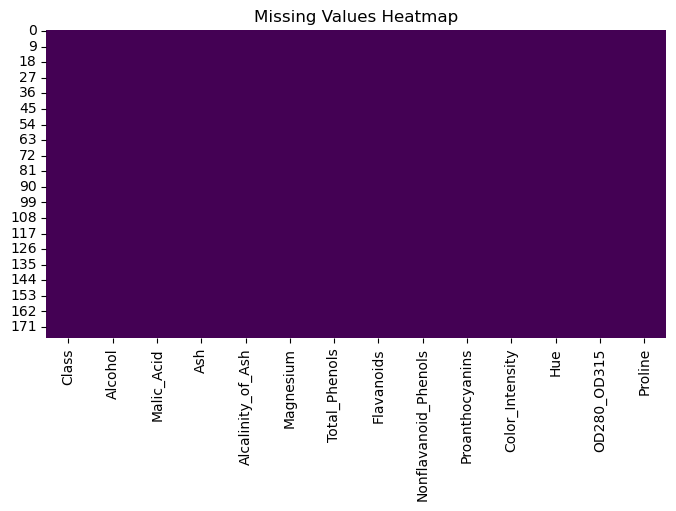

In [10]:
plt.figure(figsize=(8,4))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

In [11]:
df.duplicated().sum()

np.int64(0)

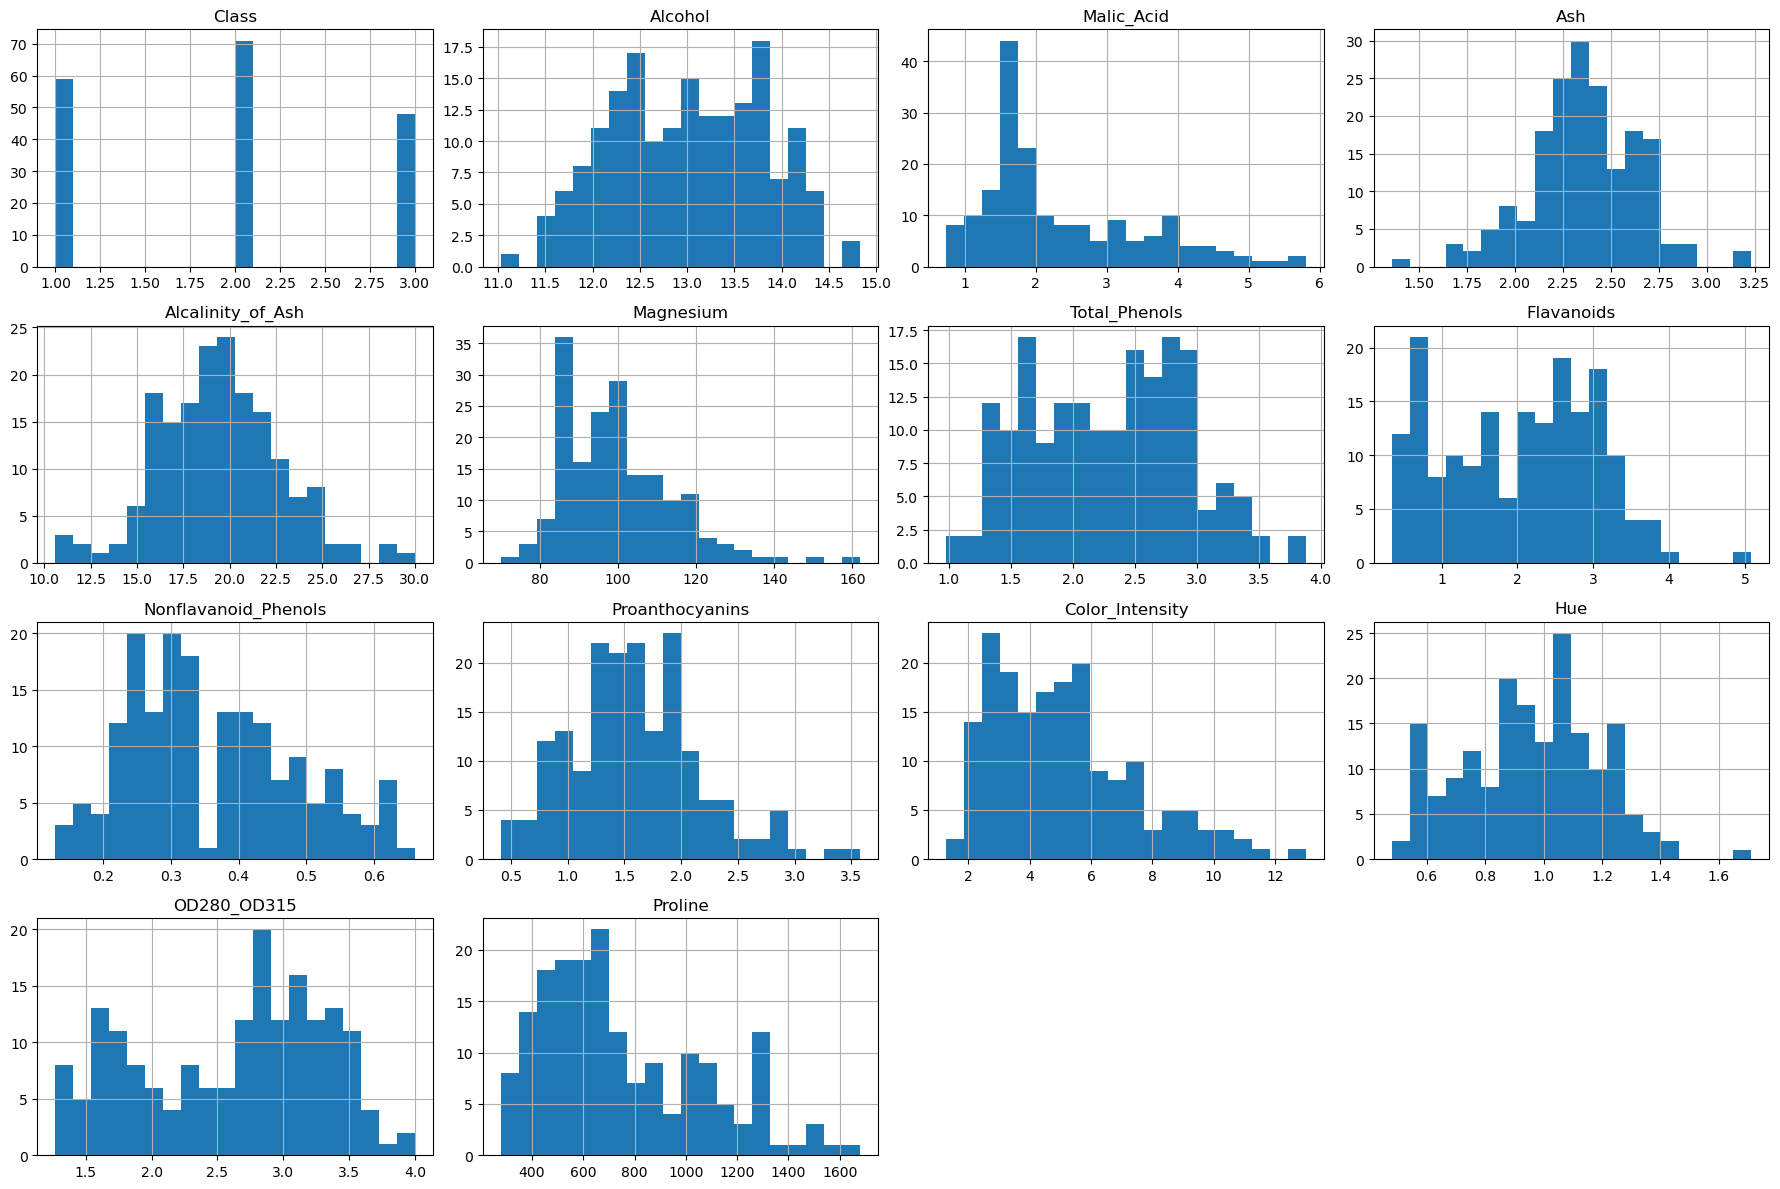

In [12]:
df.hist(figsize=(18,12),bins=20)
plt.tight_layout()
plt.show()

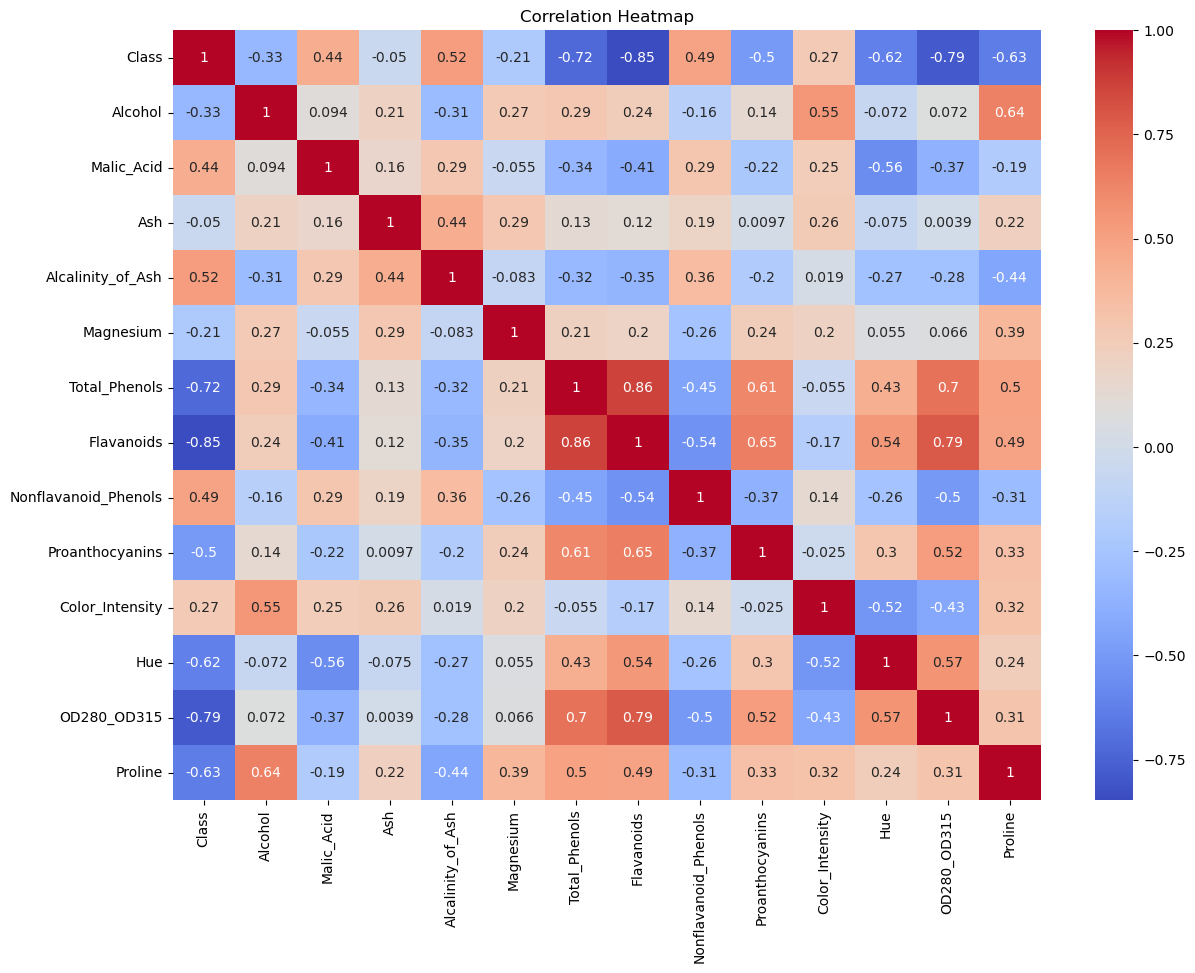

In [13]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

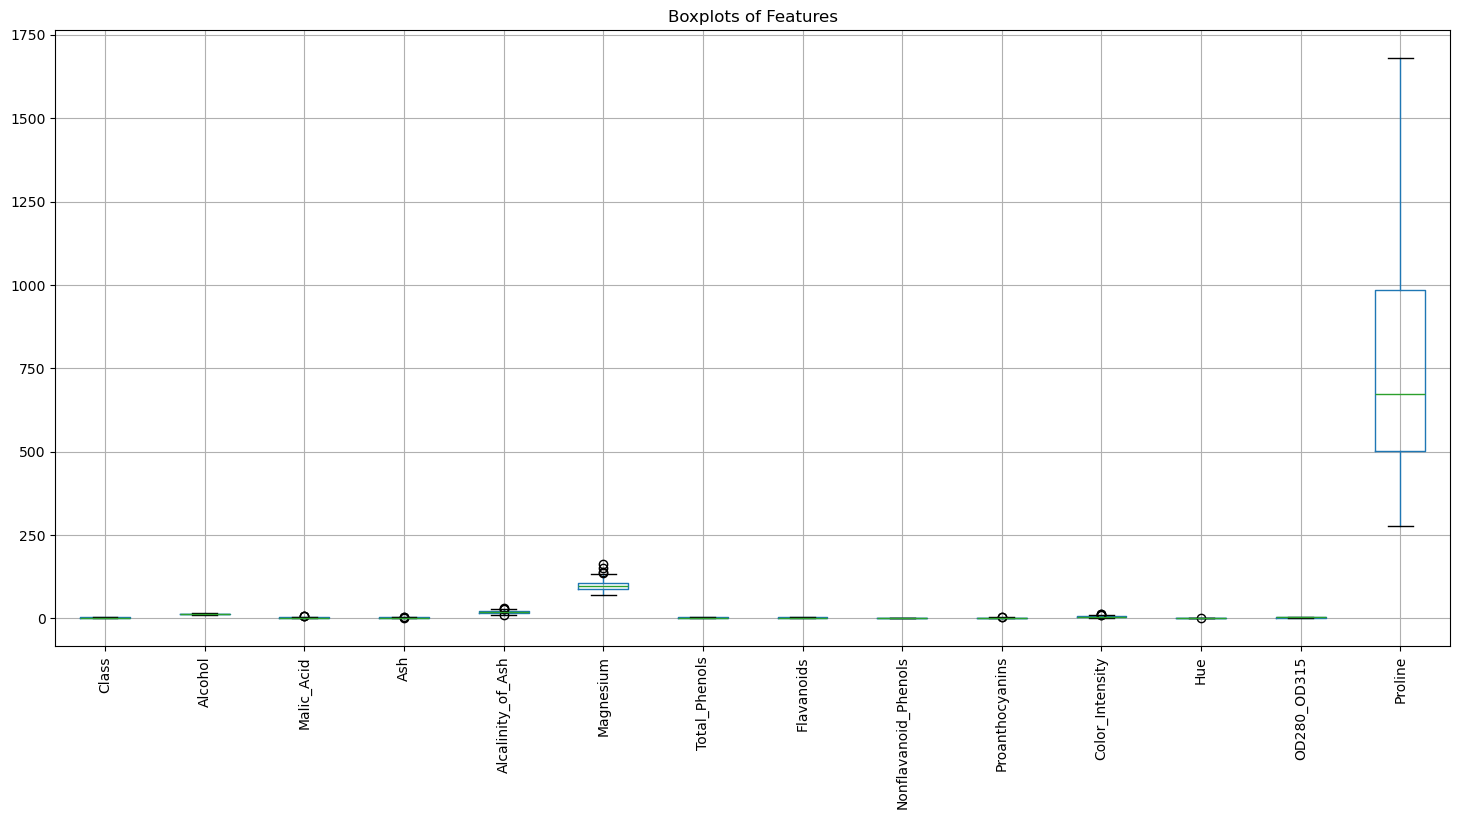

In [19]:
plt.figure(figsize=(18,8))
df.boxplot(rot=90)
plt.title("Boxplots of Features")
plt.show()

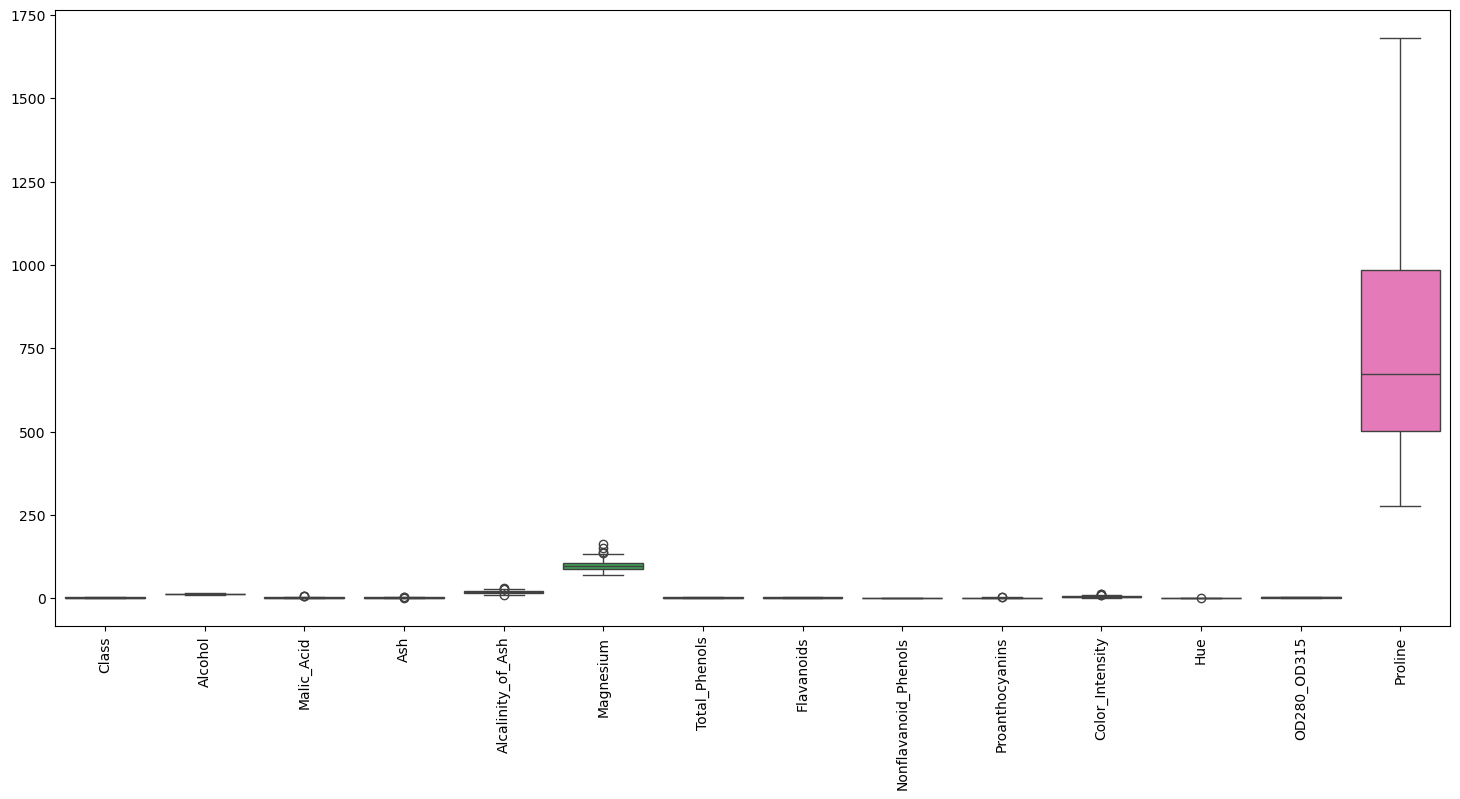

In [15]:
plt.figure(figsize=(18,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

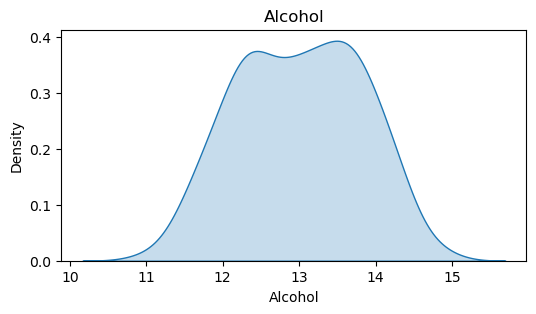

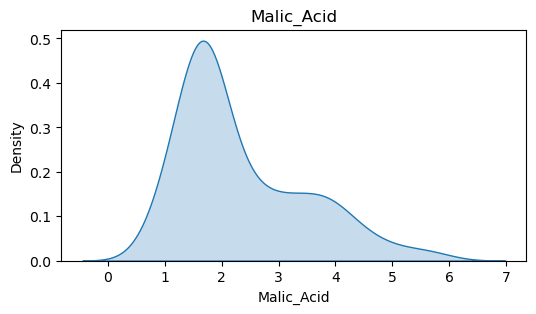

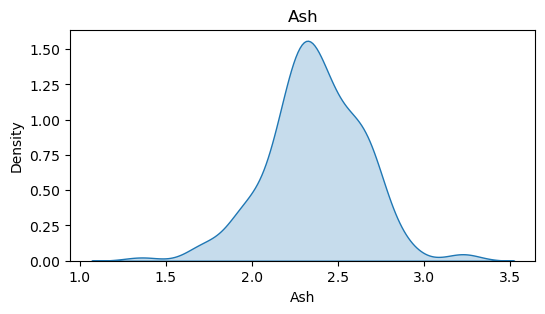

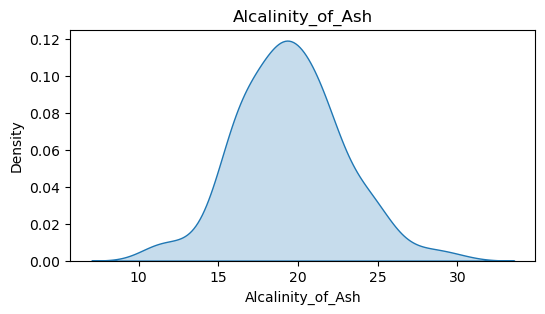

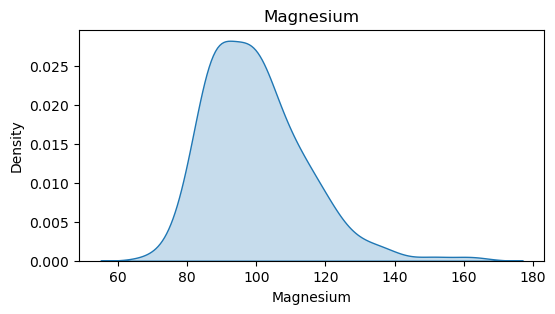

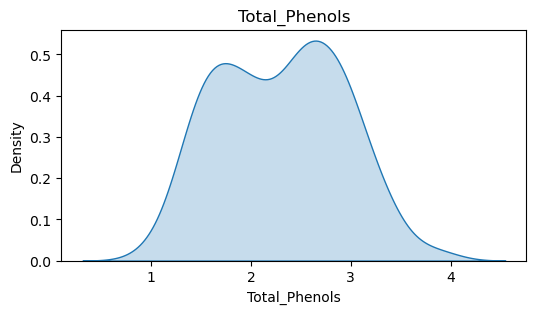

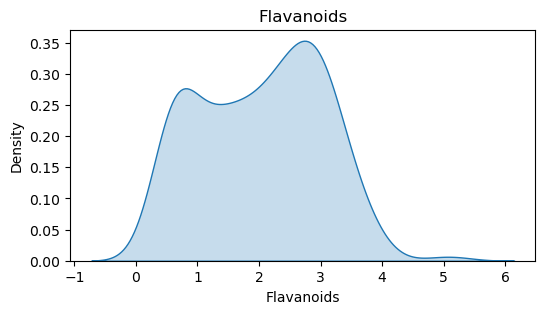

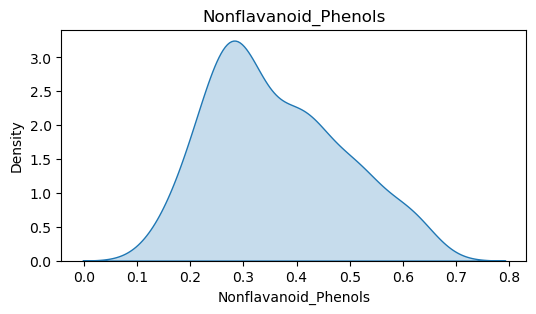

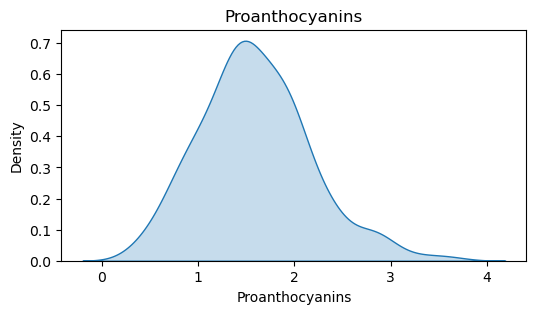

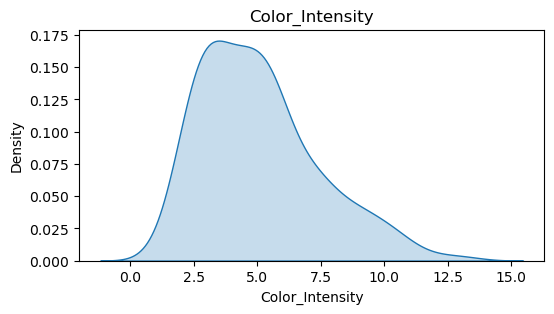

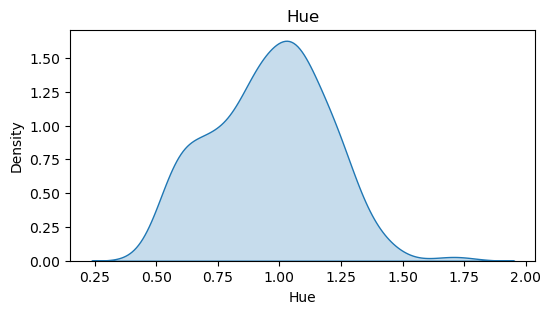

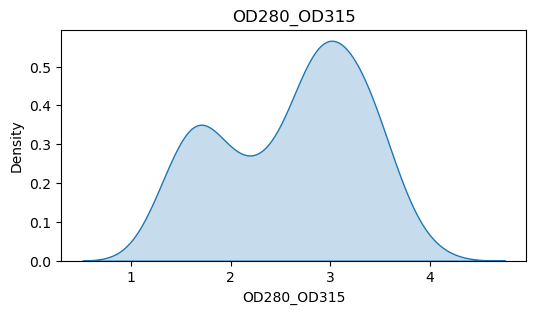

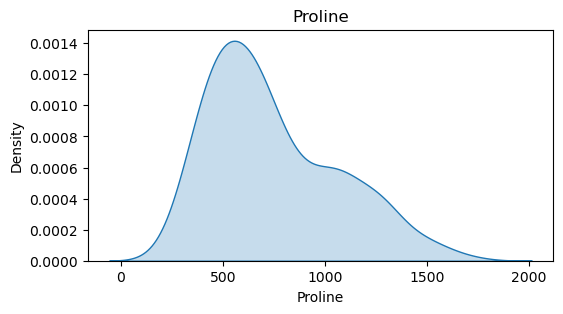

In [16]:
for col in df.columns[1:]:
    plt.figure(figsize=(6,3))
    sns.kdeplot(df[col],
                fill=True)
    plt.title(col)
    plt.show()

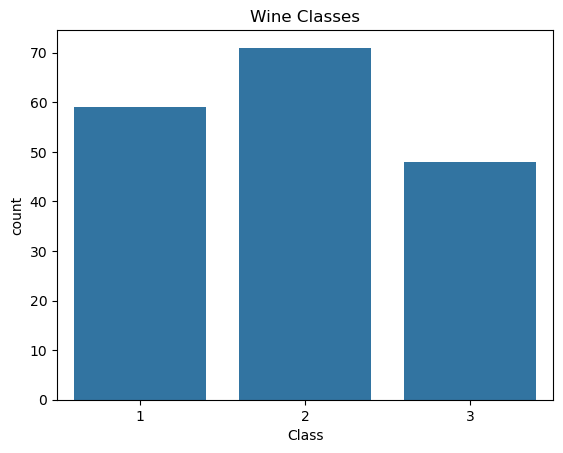

In [17]:
sns.countplot(x="Class",
              data=df)
plt.title("Wine Classes")
plt.show()

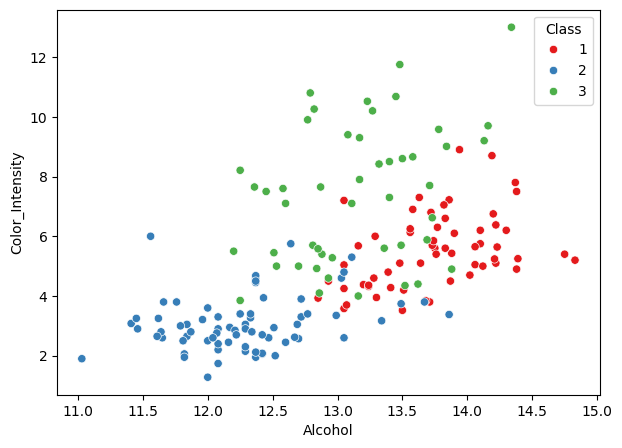

In [18]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Alcohol",
    y="Color_Intensity",
    hue="Class",
    palette="Set1"
)
plt.show()

In [20]:
X = df.drop("Class", axis=1)

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
#elbow method
wcss = []
for i in range(1,11):
    model = KMeans(n_clusters=i,random_state=42,n_init=10)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

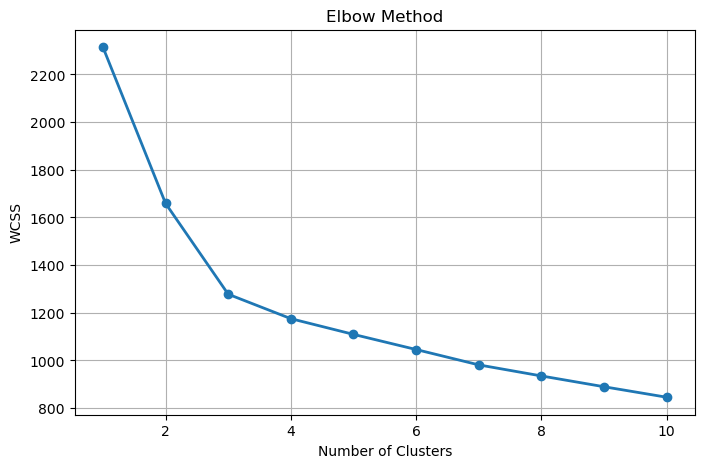

In [27]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11),
         wcss,
         marker='o',
         linewidth=2)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid()
plt.show()

In [25]:
#silhoutte scorring 
scores=[]
for i in range(2,11):
    model=KMeans(n_clusters=i,random_state=42,n_init=10)
    labels=model.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled,labels))

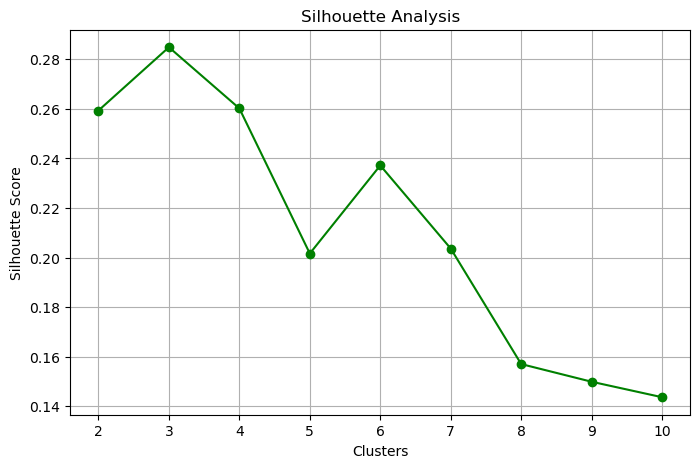

In [28]:
plt.figure(figsize=(8,5))
plt.plot(
    range(2,11),
    scores,
    marker='o',
    color='green'
)
plt.xlabel("Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.grid()
plt.show()

In [29]:
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters

In [30]:
df["Cluster"].value_counts()

Cluster
0    65
2    62
1    51
Name: count, dtype: int64

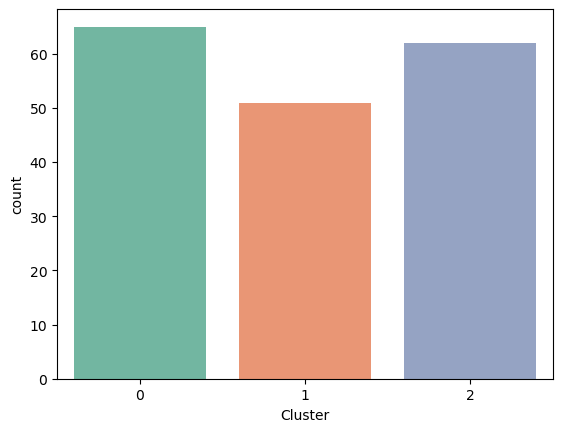

In [31]:
sns.countplot(
    x="Cluster",
    data=df,
    palette="Set2"
)
plt.show()

In [32]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

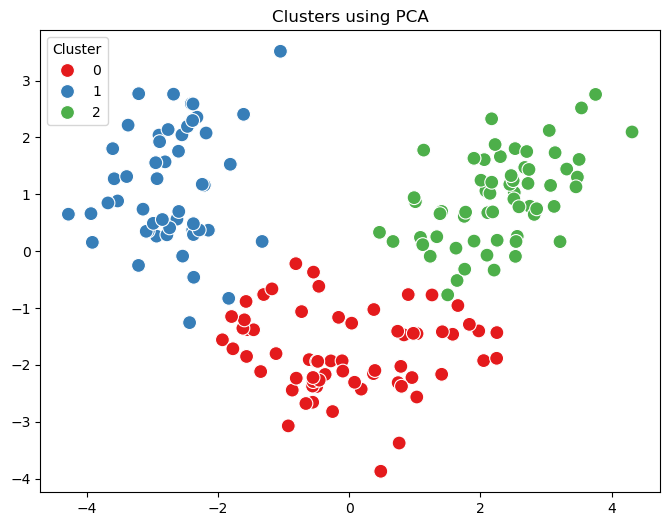

In [33]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["Cluster"],
    palette="Set1",
    s=100
)
plt.title("Clusters using PCA")
plt.show()

In [34]:
centers = scaler.inverse_transform(
    kmeans.cluster_centers_)
cluster_centers = pd.DataFrame(
    centers,
    columns=X.columns)
cluster_centers

,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231
1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824
2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806


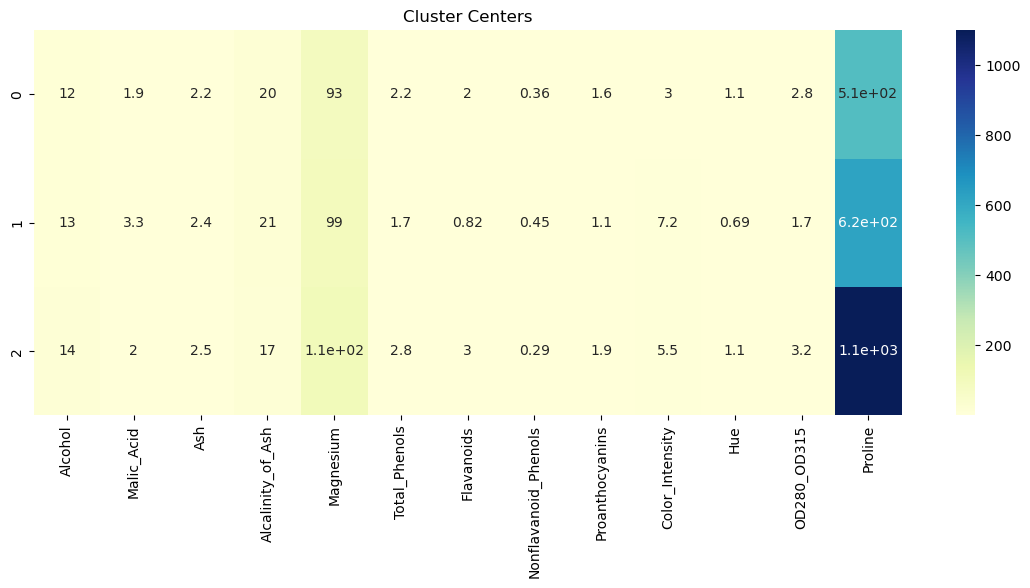

In [37]:
plt.figure(figsize=(14,5))
sns.heatmap(
    cluster_centers,
    annot=True,
    cmap="YlGnBu"
)
plt.title("Cluster Centers")
plt.show()

In [38]:
cluster_summary = df.groupby("Cluster").mean()
cluster_summary

,Class,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
Cluster,,,,,,,,,,,,,,
0,2.000000,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231
1,2.941176,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824
2,1.048387,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806


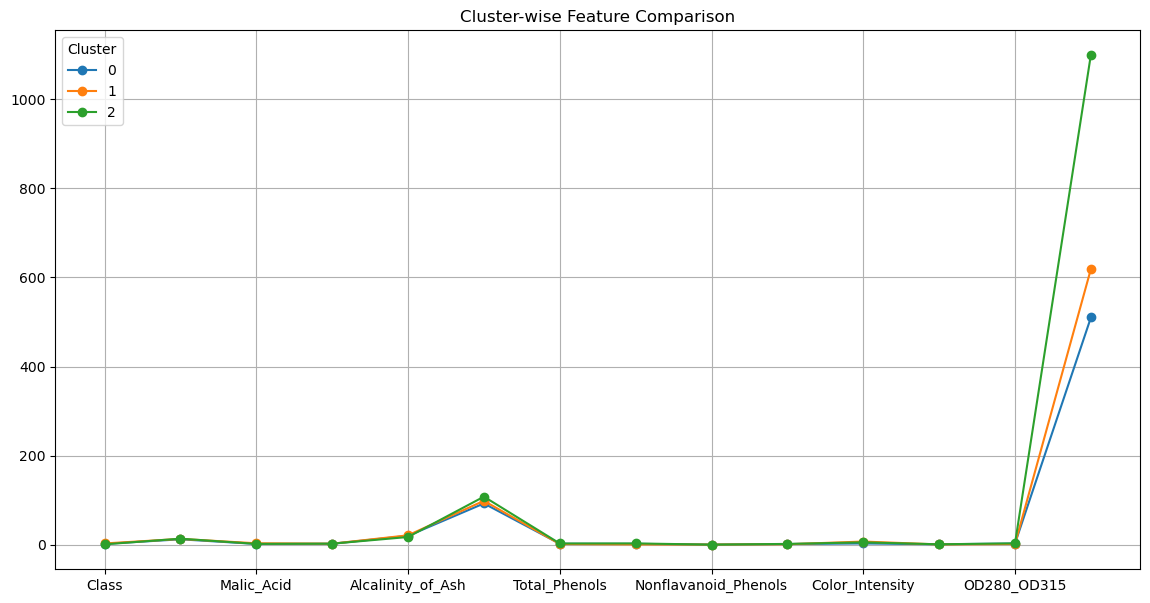

In [39]:
cluster_summary.T.plot(
    figsize=(14,7),
    marker='o'
)
plt.title("Cluster-wise Feature Comparison")
plt.grid()
plt.show()

In [40]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.28485891918989864


In [41]:
from sklearn.metrics import davies_bouldin_score
db = davies_bouldin_score(X_scaled, clusters)
print(db)

1.389187977718165


In [42]:
from sklearn.metrics import calinski_harabasz_score
ch = calinski_harabasz_score(X_scaled, clusters)
print(ch)

70.94000800315118
